In [3]:
from paper_plot import load_model_results,load_baseline_csv, merge_results
import matplotlib.pyplot as plt
import json

def results_plot_2(datasets, dataset_order):
    """
    Plot compression & decompression speed vs compression ratio:
    - X-axis: Compression Ratio
    - Y-axis: KB/s (log scale)
    - Color: Compressor model
    """
    # Manual color map for compressors
    color_map = {
        "zip": "gray",
        "gzip": "dimgray",
        "zstd -3": "lightgray",
        "zstd -1": "silver",
        "zstd -19": "darkgray",
        "distilgpt2": "silver",
        "openai-community/gpt2": "lightblue",
        "xz -9e (LZMA2)": "gainsboro",
        "Qwen/Qwen2.5-0.5B": "tab:blue",
        "Qwen/Qwen2.5-1.5B": "tab:orange",
        "Qwen/Qwen2.5-7B": "tab:green",
        "Qwen/Qwen3-0.6B": "tab:purple",
        "Qwen/Qwen3-1.7B": "tab:brown",
        "Qwen/Qwen3-8B": "tab:pink",
        "meta-llama/Llama-3.2-1B": "tab:olive",
        "HuggingFaceTB/SmolLM-135M": "tab:red",
        "HuggingFaceTB/SmolLM2-135M": "tab:cyan"
    }

    symbol_map = {
        "zip": "o",
        "gzip": "o",
        "zstd -3": "o",
        "zstd -1": "o",
        "zstd -19": "o",
        "distilgpt2": "x",
        "openai-community/gpt2": "x",
        "xz -9e (LZMA2)": "o",
        "Qwen/Qwen2.5-0.5B": "*",
        "Qwen/Qwen2.5-1.5B": "*",
        "Qwen/Qwen2.5-7B": "*",
        "Qwen/Qwen2.5-14B": "*",
        "Qwen/Qwen3-0.6B": "s",
        "Qwen/Qwen3-1.7B": "s",
        "Qwen/Qwen3-8B": "s",
        "Qwen/Qwen3-14B": "s",
        "meta-llama/Llama-3.2-1B": "D",
        "HuggingFaceTB/SmolLM-135M": "h",
        "HuggingFaceTB/SmolLM2-135M": "h"
    }

    color_order = list(color_map.keys())

    # ===== Compression Speed Plot =====
    fig_c, axes_c = plt.subplots(1, len(dataset_order), figsize=(10, 6))
    if len(dataset_order) == 1:
        axes_c = [axes_c]

    for idx, dataset in enumerate(dataset_order):
        if dataset not in datasets:
            continue
        comp_dict = datasets[dataset]
        
        ax_c = axes_c[idx]
        ax_c.set_title(f"Compression Speed - {dataset}")

        gzip_compression_ratio = comp_dict.get("gzip", {}).get("original_size_bits", 0) / comp_dict.get("gzip", {}).get("compressed_size_bits", 0)

        for comp_name, m in comp_dict.items():
            orig_bits = m["original_size_bits"]
            comp_bits = m["compressed_size_bits"]
            # ratio_percent = (comp_bits / orig_bits) * 100 if orig_bits else 0
            ratio_percent = (orig_bits / comp_bits) / gzip_compression_ratio
            speed_KBps = (orig_bits / 8 / 1024) / m["compression_time"] if m["compression_time"] > 0 else 0
            color = color_map.get(comp_name, "tab:red")
            ax_c.scatter(ratio_percent, speed_KBps, color=color, label=comp_name, marker=symbol_map.get(comp_name, 'o'))

        ax_c.set_xlabel("Compression Ratio (Normalized to Gzip)")
        ax_c.set_ylabel("Compression Speed (KB/s)")
        ax_c.set_yscale("log")
        handles, labels = ax_c.get_legend_handles_labels()
        sorted_items = sorted(
            zip(labels, handles),
            key=lambda x: color_order.index(x[0]) if x[0] in color_order else len(color_order)
        )

        sorted_labels, sorted_handles = zip(*sorted_items)
        ax_c.legend(sorted_handles, sorted_labels)

    plt.tight_layout()
    plt.show()
    plt.savefig("compression_speed_plot.png")
    # plt.savefig(
    #     f"compression_speed_plot.pdf",
    #     format="pdf",
    #     bbox_inches="tight",
    #     pad_inches=0.01,
    #     dpi=300
    # )
    plt.close()

    # ===== Decompression Speed Plot =====
    fig_d, axes_d = plt.subplots(1, len(dataset_order), figsize=(10, 6))
    if len(dataset_order) == 1:
        axes_d = [axes_d]

    for idx, dataset in enumerate(dataset_order):
        if dataset not in datasets:
            continue
        comp_dict = datasets[dataset]

        ax_d = axes_d[idx]
        ax_d.set_title(f"Decompression Speed - {dataset}")

        gzip_compression_ratio = comp_dict.get("gzip", {}).get("original_size_bits", 0) / comp_dict.get("gzip", {}).get("compressed_size_bits", 0)

        for comp_name, m in comp_dict.items():
            orig_bits = m["original_size_bits"]
            comp_bits = m["compressed_size_bits"]
            # ratio_percent = (comp_bits / orig_bits) * 100 if orig_bits else 0
            ratio_percent = (orig_bits / comp_bits) / gzip_compression_ratio
            speed_KBps = (comp_bits / 8 / 1024) / m["decompression_time"] if m["decompression_time"] > 0 else 0
            color = color_map.get(comp_name, "tab:red")
            ax_d.scatter(ratio_percent, speed_KBps, color=color, label=comp_name, marker=symbol_map.get(comp_name, 'o'))

        ax_d.set_xlabel("Compression Ratio (Normalized to Gzip)")
        ax_d.set_ylabel("Decompression Speed (KB/s)")
        ax_d.set_yscale("log")
        handles, labels = ax_d.get_legend_handles_labels()
        sorted_items = sorted(
            zip(labels, handles),
            key=lambda x: color_order.index(x[0]) if x[0] in color_order else len(color_order)
        )

        sorted_labels, sorted_handles = zip(*sorted_items)
        ax_d.legend(sorted_handles, sorted_labels)

    plt.tight_layout()
    plt.show()
    plt.savefig("decompression_speed_plot.png")
    # plt.savefig(
    #     f"decompression_speed_plot.pdf",
    #     format="pdf",
    #     bbox_inches="tight",
    #     pad_inches=0.01,
    #     dpi=300
    # )
    plt.close()

    print("Plots saved as compression_speed_plot.png and decompression_speed_plot.png")

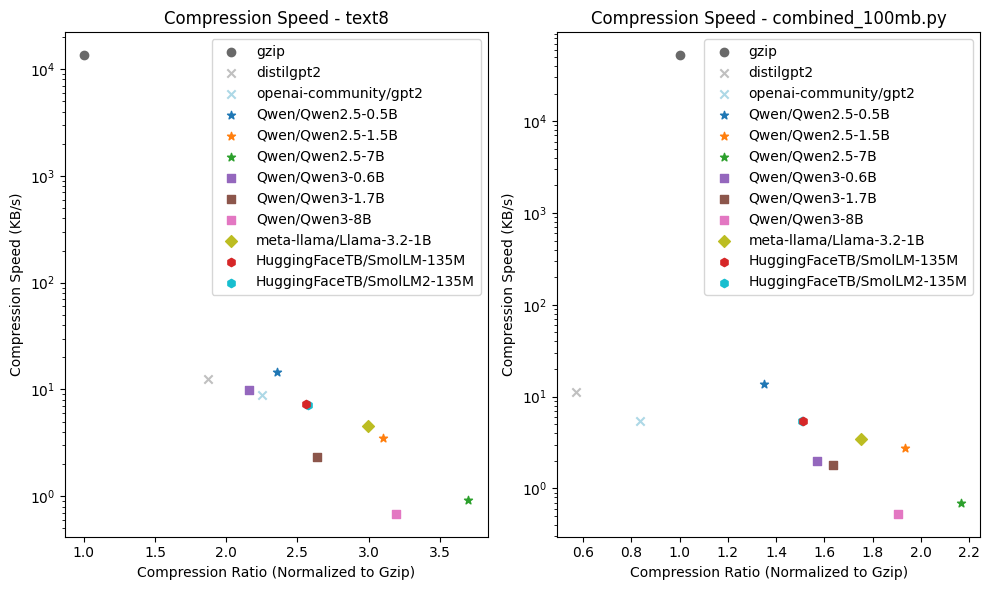

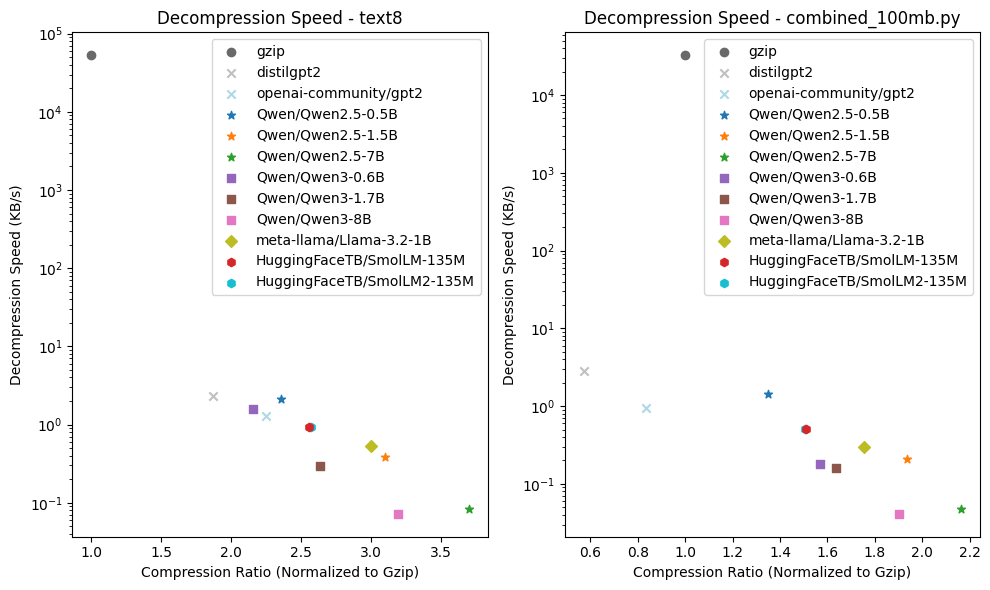

Plots saved as compression_speed_plot.png and decompression_speed_plot.png


In [6]:
dataset_order = ["text8", "combined_100mb.py"]

model_data = load_model_results(
    "compression_results_paper.json",
    selected_datasets=dataset_order,
    selected_n=[500000]
)

baseline_text8 = load_baseline_csv(
    "text8_baseline.csv",
    dataset_name="text8",
    selected_compressors=["gzip"]
)

pytorrent_data = load_baseline_csv(
    "pytorrent_baseline.csv",
    dataset_name="combined_100mb.py",
    selected_compressors=["gzip"]
)

# print("Loaded model data:", json.dumps(model_data, indent=2))

# Merge results (model + baselines)
final_data = merge_results(model_data, baseline_text8)
final_data = merge_results(final_data, pytorrent_data)

# Plot results
results_plot_2(final_data, dataset_order)

/tmp/ipykernel_17028/2650313180.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(cleaned_models, rotation=45, ha='right', fontsize=7)
/tmp/ipykernel_17028/2650313180.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(cleaned_models, rotation=45, ha='right', fontsize=7)


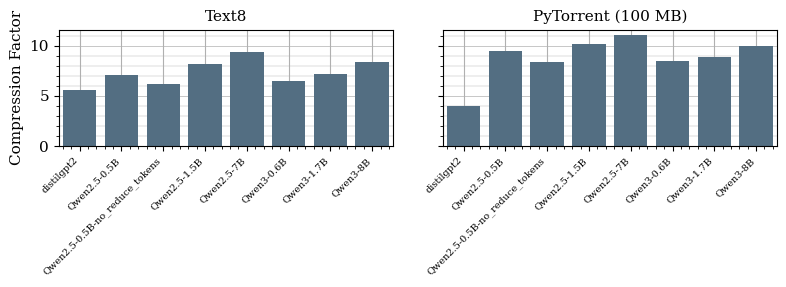

In [2]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import json

model_order = [
    "distilgpt2",
    "openai-community/gpt2",
    "Qwen/Qwen2.5-0.5B",
    "Qwen/Qwen2.5-0.5B-no_reduce_tokens",
    "Qwen/Qwen2.5-1.5B",
    "Qwen/Qwen2.5-7B",
    "Qwen/Qwen3-0.6B",
    "Qwen/Qwen3-1.7B",
    "Qwen/Qwen3-8B",
    "meta-llama/Llama-3.2-1B",
    "HuggingFaceTB/SmolLM-135M",
    "HuggingFaceTB/SmolLM2-135M"
]

model_order = [
    "distilgpt2",
    "Qwen/Qwen2.5-0.5B",
    "Qwen/Qwen2.5-0.5B-no_reduce_tokens",
    "Qwen/Qwen2.5-1.5B",
    "Qwen/Qwen2.5-7B",
    "Qwen/Qwen3-0.6B",
    "Qwen/Qwen3-1.7B",
    "Qwen/Qwen3-8B"
]

# Load the data from JSON file
with open("compression_results_plot.json", "r") as f:
    data = json.load(f)

# Convert data to DataFrame
rows = []
for dataset, models in data.items():
    for model, vals in models.items():
        comp_factor = vals["original_size_bits"] / vals["compressed_size_bits"]
        rows.append({"Dataset": dataset, "Technique": model, "Compression Factor": comp_factor})
df = pd.DataFrame(rows)

# Sort models by color_map order
df["Technique"] = pd.Categorical(df["Technique"], categories=model_order, ordered=True)

# Plot settings
matplotlib.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'medium',
    'text.usetex': False
})

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
datasets = ["text8", "combined_100mb.py"]
titles = ["Text8", "PyTorrent (100 MB)"]

for i, dataset in enumerate(datasets):
    subset = df[df["Dataset"] == dataset]
    sns.barplot(
        x="Technique",
        y="Compression Factor",
        data=subset,
        ax=axes[i],
        order=model_order,
        color='#4B6F8A'
    )
    axes[i].set_title(titles[i])
    cleaned_models = [m.split("/", 1)[-1] if "/" in m else m for m in model_order]
    axes[i].set_xticklabels(cleaned_models, rotation=45, ha='right', fontsize=7)
    axes[i].grid(zorder=0)
    axes[i].set_axisbelow(True)
    axes[i].set_xlabel("")

for ax in axes:
    ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
    ax.yaxis.grid(True, which='minor', linestyle='-', linewidth=0.3, zorder=0)
    ax.minorticks_on()

plt.tight_layout()
plt.savefig("compression_factors_ordered.pdf", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

/tmp/ipykernel_80457/1656284819.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(cleaned_models, rotation=45, ha='right', fontsize=7)
/tmp/ipykernel_80457/1656284819.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(cleaned_models, rotation=45, ha='right', fontsize=7)


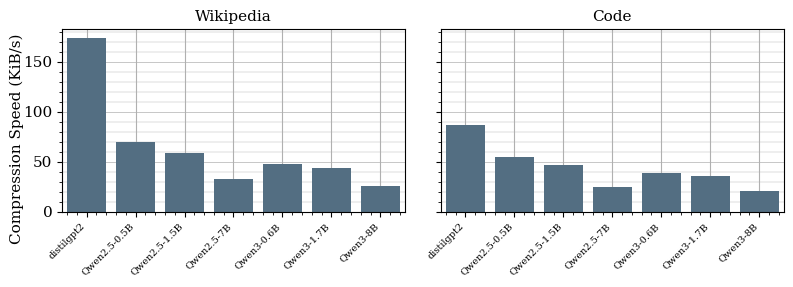

In [11]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import json

model_order = [
    "distilgpt2",
    "openai-community/gpt2",
    "Qwen/Qwen2.5-0.5B",
    "Qwen/Qwen2.5-0.5B-no_reduce_tokens",
    "Qwen/Qwen2.5-1.5B",
    "Qwen/Qwen2.5-7B",
    "Qwen/Qwen3-0.6B",
    "Qwen/Qwen3-1.7B",
    "Qwen/Qwen3-8B",
    "meta-llama/Llama-3.2-1B",
    "HuggingFaceTB/SmolLM-135M",
    "HuggingFaceTB/SmolLM2-135M"
]

model_order = [
    "distilgpt2",
    "Qwen/Qwen2.5-0.5B",
    "Qwen/Qwen2.5-1.5B",
    "Qwen/Qwen2.5-7B",
    "Qwen/Qwen3-0.6B",
    "Qwen/Qwen3-1.7B",
    "Qwen/Qwen3-8B"
]

# Load the data from JSON file
with open("compression_results.json", "r") as f:
    data = json.load(f)

# Convert data to DataFrame
rows = []
for key, content in data.items():
    comp = content.get("compression", {})
    args = comp.get("args", {})
    dataset = args.get("input_path", "").replace("./data/", "")
    model = args.get("model_name", "")
    # orig_bytes = comp.get("original_size_bytes", 0)
    # comp_time = comp.get("total_compression_time", 0)
    compression_factor = comp.get("compression_factor", 0)
    comp_speed_kib = comp.get("throughput_kibibytes_per_sec", 0)  # KiB/s
    comp_speed_inference_kib = comp.get("inference_throughput_kibibytes_per_sec", 0)  # KiB/s
    
    rows.append({
        "Dataset": dataset,
        "Technique": model,
        "Compression Speed (KiB/s)": comp_speed_inference_kib
    })

df = pd.DataFrame(rows)

# Sort models by color_map order
df["Technique"] = pd.Categorical(df["Technique"], categories=model_order, ordered=True)

# Plot settings
matplotlib.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'medium',
    'text.usetex': False
})

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
datasets = ["text8", "combined_100mb.py"]
titles = ["Wikipedia", "Code"]

for i, dataset in enumerate(datasets):
    subset = df[df["Dataset"] == dataset]
    sns.barplot(
        x="Technique",
        y="Compression Speed (KiB/s)",
        data=subset,
        ax=axes[i],
        order=model_order,
        color='#4B6F8A'
    )
    axes[i].set_title(titles[i])
    cleaned_models = [m.split("/", 1)[-1] if "/" in m else m for m in model_order]
    axes[i].set_xticklabels(cleaned_models, rotation=45, ha='right', fontsize=7)
    axes[i].grid(zorder=0)
    axes[i].set_axisbelow(True)
    axes[i].set_xlabel("")

for ax in axes:
    ax.set_ylabel("Compression Speed (KiB/s)")
    ax.yaxis.set_label_coords(-0.11, 0.4)
    ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
    ax.yaxis.grid(True, which='minor', linestyle='-', linewidth=0.3, zorder=0)
    ax.minorticks_on()

plt.tight_layout()
plt.savefig("compression_speed_ordered.pdf", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

/tmp/ipykernel_80457/3515002625.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(cleaned_models, rotation=45, ha='right', fontsize=7)
/tmp/ipykernel_80457/3515002625.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(cleaned_models, rotation=45, ha='right', fontsize=7)


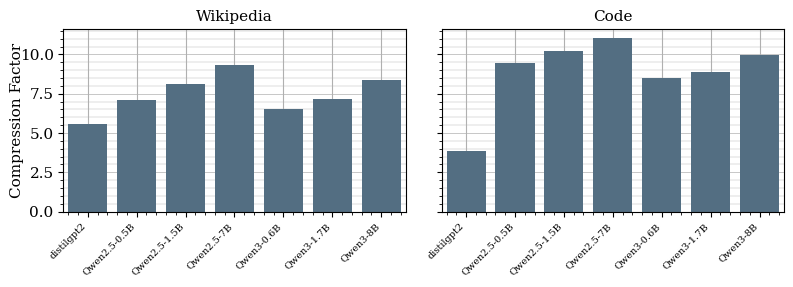

In [12]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import json

# model_order = [
#     "distilgpt2",
#     "openai-community/gpt2",
#     "Qwen/Qwen2.5-0.5B",
#     "Qwen/Qwen2.5-0.5B-no_reduce_tokens",
#     "Qwen/Qwen2.5-1.5B",
#     "Qwen/Qwen2.5-7B",
#     "Qwen/Qwen3-0.6B",
#     "Qwen/Qwen3-1.7B",
#     "Qwen/Qwen3-8B",
#     "meta-llama/Llama-3.2-1B",
#     "HuggingFaceTB/SmolLM-135M",
#     "HuggingFaceTB/SmolLM2-135M"
# ]

model_order = [
    "distilgpt2",
    "Qwen/Qwen2.5-0.5B",
    "Qwen/Qwen2.5-1.5B",
    "Qwen/Qwen2.5-7B",
    "Qwen/Qwen3-0.6B",
    "Qwen/Qwen3-1.7B",
    "Qwen/Qwen3-8B"
]

# Load the data from JSON file
with open("compression_results.json", "r") as f:
    data = json.load(f)

# Convert data to DataFrame
rows = []
for key, content in data.items():
    comp = content.get("compression", {})
    args = comp.get("args", {})
    dataset = args.get("input_path", "").replace("./data/", "")
    model = args.get("model_name", "")
    orig_bytes = comp.get("original_size_bytes", 0)
    comp_time = comp.get("total_compression_time", 0)
    compression_factor = comp.get("compression_factor", 0)
    comp_speed_kib = comp.get("throughput_kibibytes_per_sec", 0)  # KiB/s
    comp_speed_inference_kib = comp.get("inference_throughput_kibibytes_per_sec", 0)  # KiB/s
    
    rows.append({
        "Dataset": dataset,
        "Technique": model,
        "Compression Factor": compression_factor
    })

df = pd.DataFrame(rows)

# Sort models by color_map order
df["Technique"] = pd.Categorical(df["Technique"], categories=model_order, ordered=True)

# Plot settings
matplotlib.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.titlesize': 'medium',
    'figure.titlesize': 'medium',
    'text.usetex': False
})

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
datasets = ["text8", "combined_100mb.py"]
titles = ["Wikipedia", "Code"]

for i, dataset in enumerate(datasets):
    subset = df[df["Dataset"] == dataset]
    sns.barplot(
        x="Technique",
        y="Compression Factor",
        data=subset,
        ax=axes[i],
        order=model_order,
        color='#4B6F8A'
    )
    axes[i].set_title(titles[i])
    cleaned_models = [m.split("/", 1)[-1] if "/" in m else m for m in model_order]
    axes[i].set_xticklabels(cleaned_models, rotation=45, ha='right', fontsize=7)
    axes[i].grid(zorder=0)
    axes[i].set_axisbelow(True)
    axes[i].set_xlabel("")

for ax in axes:
    ax.set_ylabel("Compression Factor")
    ax.yaxis.set_label_coords(-0.115, 0.5)
    ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.5, zorder=0)
    ax.yaxis.grid(True, which='minor', linestyle='-', linewidth=0.3, zorder=0)
    ax.minorticks_on()

plt.tight_layout()
plt.savefig("compression_factor_ordered.pdf", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()